In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
df=pd.read_csv('laptop_data.csv')

In [26]:
df.shape

(1303, 12)

In [27]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [29]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [30]:
df.duplicated().sum()

0

In [31]:
df=df.drop(columns=['Unnamed: 0'])

In [32]:
df.isnull().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [33]:
df['Ram']=df['Ram'].str.replace('GB','')

In [34]:
df['Weight']=df['Weight'].str.replace('kg','')

In [35]:
df['Ram']=df['Ram'].astype('int32')
df['Weight']=df['Weight'].astype('float32')

<Axes: xlabel='Price', ylabel='Density'>

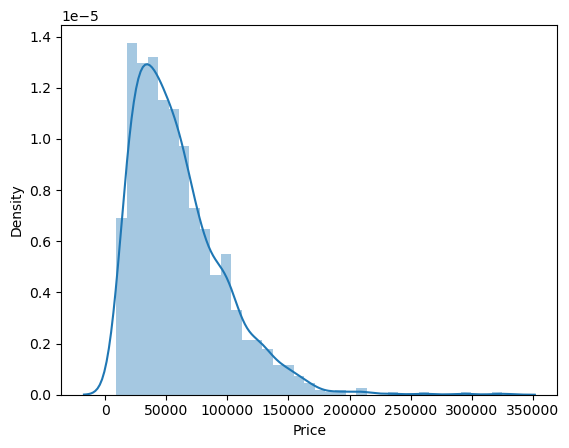

In [36]:
sns.distplot(df['Price'])

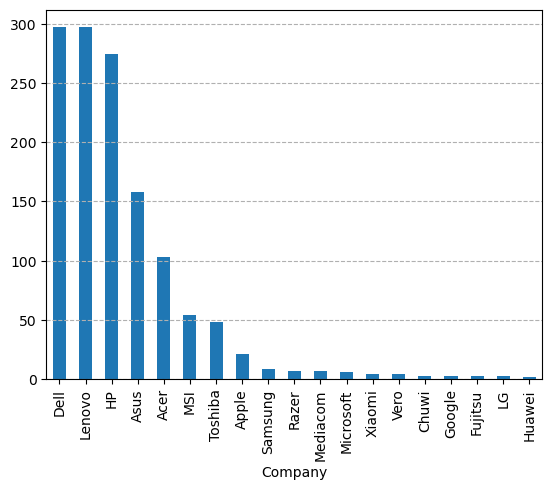

In [37]:
df['Company'].value_counts().plot(kind='bar')
plt.grid(axis='y',linestyle='--')

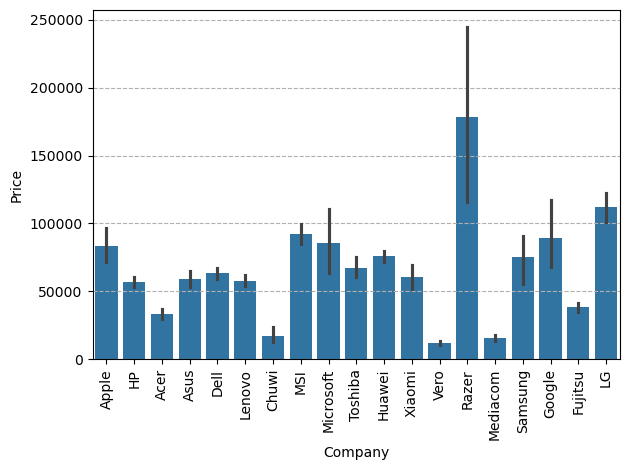

In [38]:
sns.barplot(x=df['Company'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()

<Axes: xlabel='TypeName'>

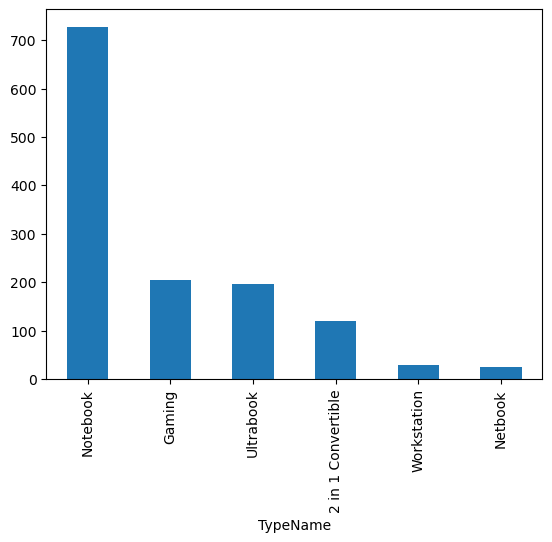

In [39]:
df['TypeName'].value_counts().plot(kind='bar')

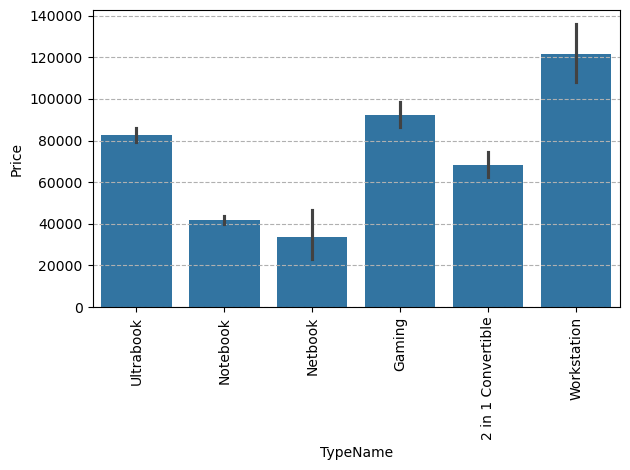

In [40]:
sns.barplot(x=df['TypeName'],y=df['Price'])
plt.xticks(rotation='vertical')
plt.grid(axis='y',linestyle='--')
plt.tight_layout()
plt.show()

<Axes: xlabel='Inches', ylabel='Density'>

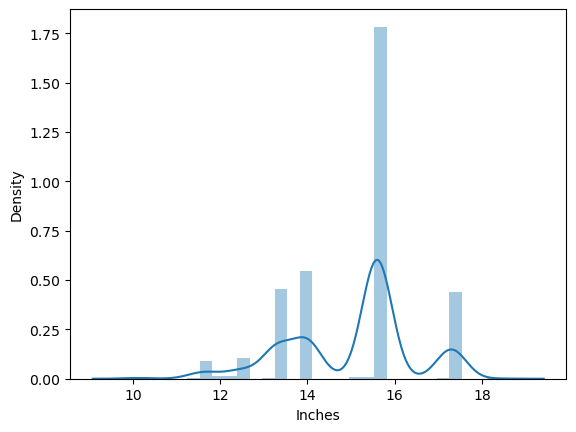

In [41]:
sns.distplot(df['Inches'])

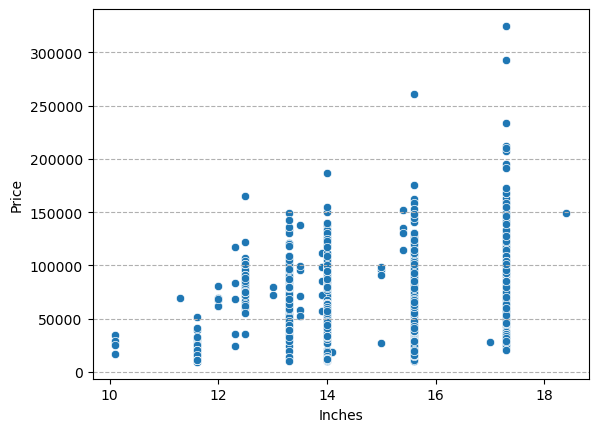

In [42]:
sns.scatterplot(x=df['Inches'],y=df['Price'])
plt.grid(axis='y',linestyle='--')

In [43]:
df['ScreenResolution'].value_counts()

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x14

In [44]:
df['TouchScreen']=df['ScreenResolution'].apply(lambda x:1 if "Touchscreen" in x else 0)

<Axes: xlabel='TouchScreen'>

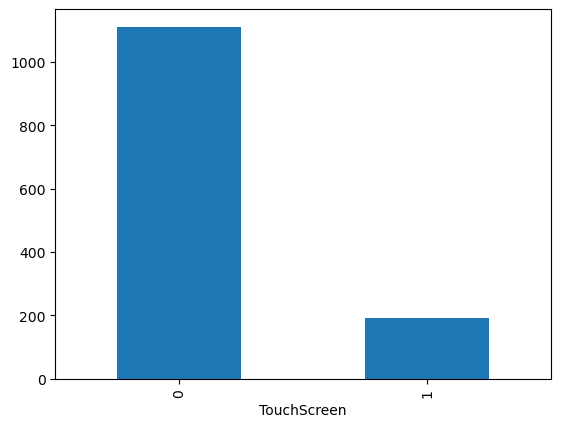

In [45]:
df['TouchScreen'].value_counts().plot(kind='bar')

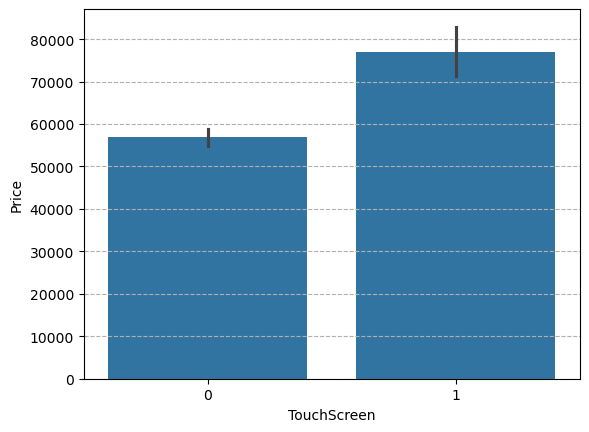

In [46]:
sns.barplot(x=df['TouchScreen'],y=df['Price'])
plt.grid(axis='y',linestyle='--')

In [48]:
df['IPS']=df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

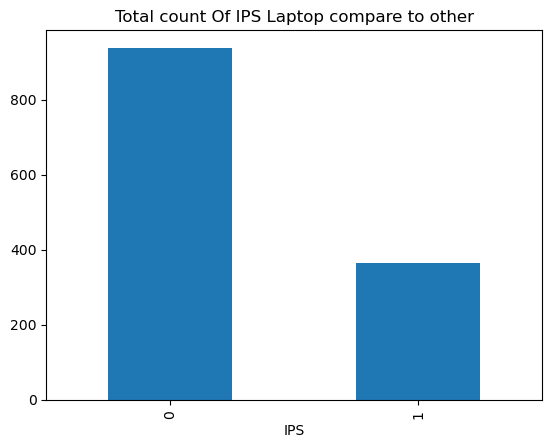

In [58]:
df['IPS'].value_counts().plot(kind='bar')
plt.title("Total count Of IPS Laptop compare to other")
plt.show()

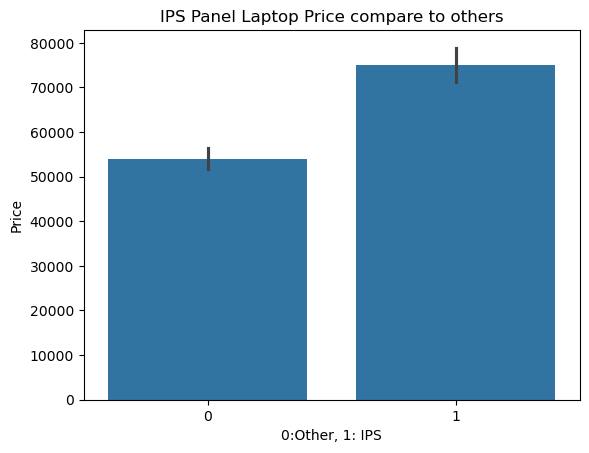

In [56]:
sns.barplot(x=df['IPS'],y=df['Price'])
plt.title('IPS Panel Laptop Price compare to others')
plt.xlabel('0:Other, 1: IPS')
plt.show()

<Axes: xlabel='TouchScreen', ylabel='IPS'>

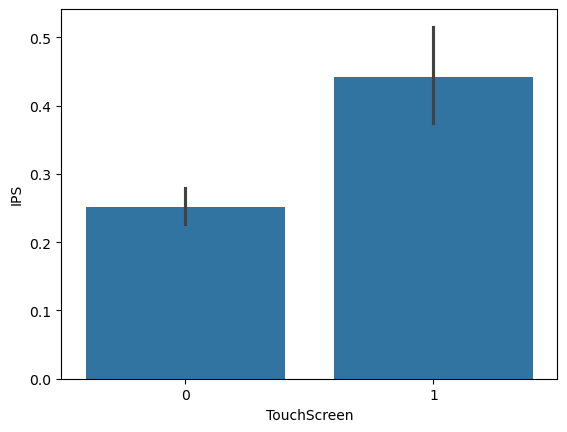

In [59]:
sns.barplot(x=df['TouchScreen'],y=df['IPS'])